# Scratch baselines without SAM — CustomCNN, ResNet18, ViT
- Same preprocessing, cosine+warmup schedule, early stopping on AUROC.
- Final metrics shown at 0.5 and at a *recall‑first* operating point (screening).


In [8]:
# Make sure Python can import the package by name:
import sys
from pathlib import Path

# If the notebook is inside notebooks/, add the parent (project root) to sys.path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("sys.path[0] =", sys.path[0])

# Now import from the package by name (ABSOLUTE import, no leading dot)
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project


device(type='mps')

In [9]:
# === Paths/config ===
DATASET_DIR = Path("../Data/chest_xray")  # <--- EDIT THIS PATH

# Data config
data_cfg = DataCfg(dataset_dir=DATASET_DIR, image_size=224,
                   use_stratified_val=True, stratified_val_size=0.15,
                   batch_size=32, num_workers=0, pin_memory=True)

# Scratch recipe (aligned with 2106.01548, scaled to this dataset)
scratch_cfg = TrainCfg(
    epochs=100, patience=15, monitor="va_auroc",
    base_lr=3e-4, weight_decay=0.3,     # ViT/AdamW defaults; CNN/ResNet builder uses SGD 0.1, WD 1e-3
    clip_grad_norm=1.0, use_amp=False,
    use_sam=False, sam_rho=0.2,         # SAM OFF in this notebook
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    target_recall=0.95,
    llrd=False, head_lr_mult=10.0,
)

# Load data
train_loader, val_loader, test_loader, info = build_dataloaders(
    data_cfg.dataset_dir, data_cfg.image_size, data_cfg.batch_size,
    data_cfg.num_workers, data_cfg.pin_memory,
    data_cfg.use_stratified_val, data_cfg.stratified_val_size
)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Class weights for imbalance
arr = np.array(info["train_counts"], dtype=float); w = arr.sum() / (len(arr) * (arr + 1e-9))
class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4447 785 624
Train counts: [1147, 3300]


[CustomCNN-scratch] epoch 01/100  tr_loss=0.4739  val_loss=0.8068  val_acc=0.5618  val_f1=0.5815  val_auroc=0.9405  (no_improve=0)
[CustomCNN-scratch] epoch 02/100  tr_loss=0.4632  val_loss=0.3289  val_acc=0.8726  val_f1=0.9107  val_auroc=0.9378  (no_improve=1)
[CustomCNN-scratch] epoch 03/100  tr_loss=0.4527  val_loss=0.3748  val_acc=0.8268  val_f1=0.8731  val_auroc=0.9202  (no_improve=2)
[CustomCNN-scratch] epoch 04/100  tr_loss=0.4390  val_loss=0.3591  val_acc=0.8535  val_f1=0.8942  val_auroc=0.9256  (no_improve=3)
[CustomCNN-scratch] epoch 05/100  tr_loss=0.4128  val_loss=0.6423  val_acc=0.6892  val_f1=0.7365  val_auroc=0.9352  (no_improve=4)
[CustomCNN-scratch] epoch 06/100  tr_loss=0.4038  val_loss=0.4413  val_acc=0.8484  val_f1=0.9021  val_auroc=0.9333  (no_improve=5)
[CustomCNN-scratch] epoch 07/100  tr_loss=0.3813  val_loss=0.4401  val_acc=0.8459  val_f1=0.8998  val_auroc=0.9325  (no_improve=6)
[CustomCNN-scratch] epoch 08/100  tr_loss=0.3858  val_loss=0.5043  val_acc=0.8242  

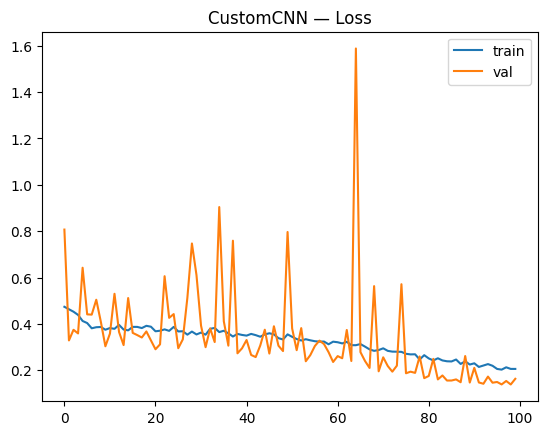

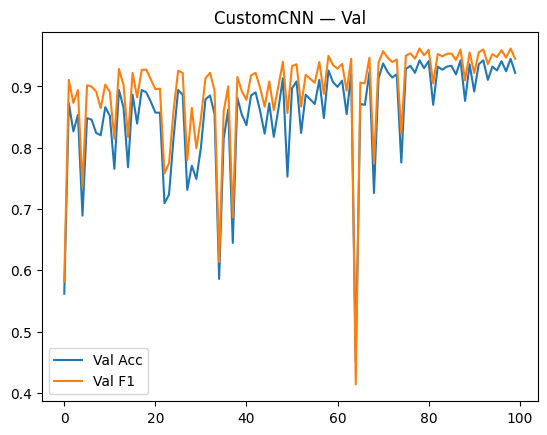

[CustomCNN @0.5] {'acc': 0.9087, 'precision': 0.8974, 'recall': 0.9641, 'f1': 0.9295, 'auroc': 0.9523, 'thr': 0.5}
[CustomCNN @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.9523, 'thr': 0.0001}


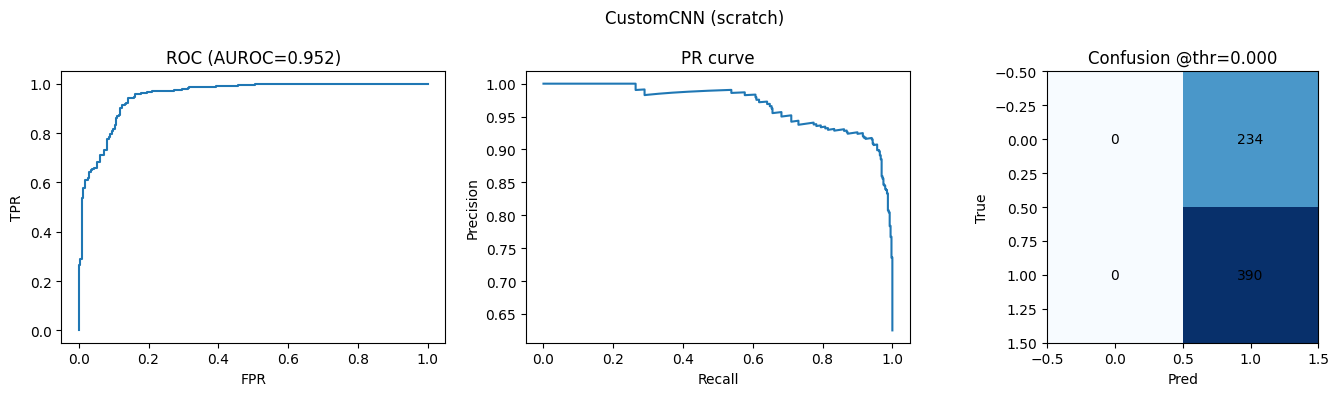

{'summary@0.5': {'acc': 0.9086538461538461,
  'precision': 0.8973747016706444,
  'recall': 0.9641025641025641,
  'f1': 0.9295426452410384,
  'auroc': 0.9523011176857331,
  'thr': 0.5},
 'summary@recall': {'acc': 0.625,
  'precision': 0.625,
  'recall': 1.0,
  'f1': 0.7692307692307693,
  'auroc': 0.9523011176857331,
  'thr': 7.381265459116548e-05},
 'threshold': 7.381265459116548e-05,
 'time_sec': 10275.340657949448,
 'params': 481698}

In [10]:
cfg = scratch_cfg

cnn = build_custom_cnn(num_classes=2, width=32, dropout=0.0)
t0 = time.time()
cnn_tr, cnn_hist, cnn_time = train_model(
    cnn, train_loader, val_loader, DEVICE, arch="custom_cnn",
    epochs=cfg.epochs, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.02,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="CustomCNN-scratch"
)
cnn_time = time.time() - t0

plot_curve(cnn_hist['tr_loss'], cnn_hist['va_loss'], "CustomCNN — Loss")
plot_two_series(cnn_hist['va_acc'], "Val Acc", cnn_hist['va_f1'], "Val F1", "CustomCNN — Val")

va = evaluate(cnn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(cnn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[CustomCNN @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[CustomCNN @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("CustomCNN (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("CustomCNN (scratch)", cnn_tr, sum_05, sum_reca, threshold=thr, time_sec=cnn_time)


[ResNet18-scratch] epoch 01/90  tr_loss=0.5375  val_loss=0.4673  val_acc=0.8624  val_f1=0.9128  val_auroc=0.9407  (no_improve=0)
[ResNet18-scratch] epoch 02/90  tr_loss=0.5567  val_loss=0.4847  val_acc=0.8815  val_f1=0.9240  val_auroc=0.9511  (no_improve=0)
[ResNet18-scratch] epoch 03/90  tr_loss=0.5482  val_loss=1.3766  val_acc=0.2573  val_f1=0.0000  val_auroc=0.8775  (no_improve=1)
[ResNet18-scratch] epoch 04/90  tr_loss=0.5332  val_loss=1.8802  val_acc=0.8803  val_f1=0.9228  val_auroc=0.9320  (no_improve=2)
[ResNet18-scratch] epoch 05/90  tr_loss=0.4325  val_loss=0.3093  val_acc=0.9274  val_f1=0.9513  val_auroc=0.9732  (no_improve=0)
[ResNet18-scratch] epoch 06/90  tr_loss=0.4232  val_loss=0.2772  val_acc=0.8726  val_f1=0.9081  val_auroc=0.9718  (no_improve=1)
[ResNet18-scratch] epoch 07/90  tr_loss=0.3745  val_loss=0.3692  val_acc=0.8968  val_f1=0.9305  val_auroc=0.9609  (no_improve=2)
[ResNet18-scratch] epoch 08/90  tr_loss=0.3702  val_loss=0.3344  val_acc=0.8013  val_f1=0.8462  v

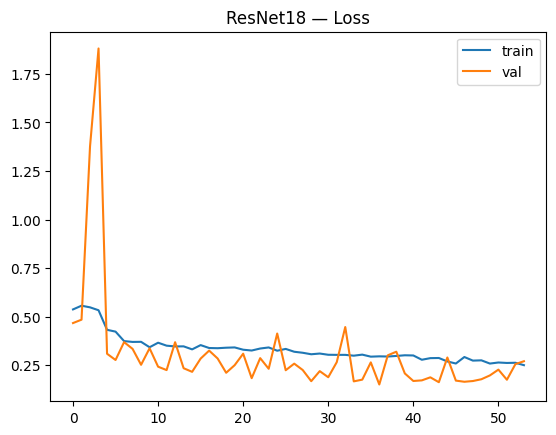

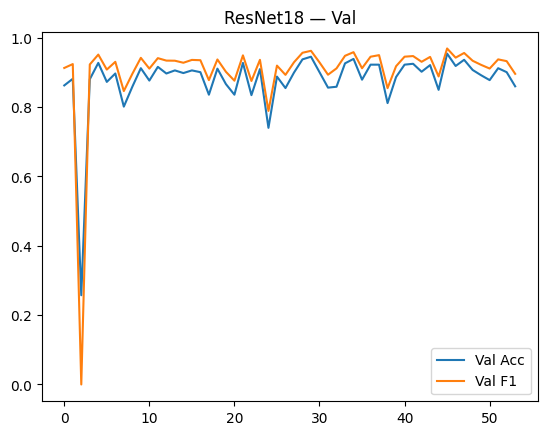

[ResNet18-scratch @0.5] {'acc': 0.8205, 'precision': 0.9112, 'recall': 0.7897, 'f1': 0.8462, 'auroc': 0.929, 'thr': 0.5}
[ResNet18-scratch @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.929, 'thr': 0.0}


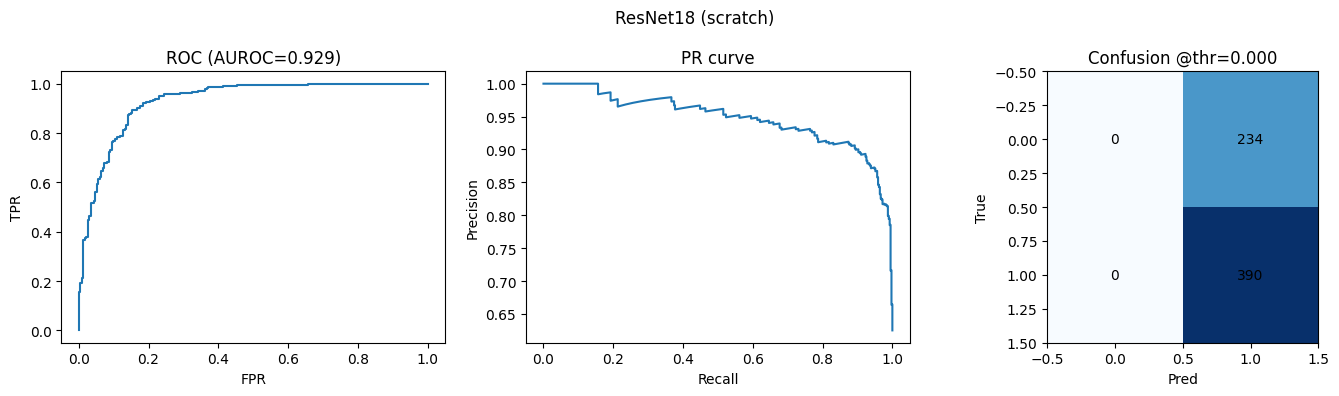

{'summary@0.5': {'acc': 0.8205128205128205,
  'precision': 0.9112426035502958,
  'recall': 0.7897435897435897,
  'f1': 0.8461538461538461,
  'auroc': 0.9290379136532982,
  'thr': 0.5},
 'summary@recall': {'acc': 0.625,
  'precision': 0.625,
  'recall': 1.0,
  'f1': 0.7692307692307693,
  'auroc': 0.9290379136532982,
  'thr': 9.46163072512718e-06},
 'threshold': 9.46163072512718e-06,
 'time_sec': 25128.17983698845,
 'params': 11177538}

In [11]:
rn = build_resnet18(in_chans=3, num_classes=2, pretrained=False, conv_stem=False)
t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=90, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.05,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-scratch"
)
rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-scratch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-scratch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (scratch)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-scratch] epoch 01/100  tr_loss=0.6689  val_loss=0.4007  val_acc=0.8650  val_f1=0.9096  val_auroc=0.9319  (no_improve=0)
[ViT-scratch] epoch 02/100  tr_loss=0.5877  val_loss=0.3807  val_acc=0.7771  val_f1=0.8266  val_auroc=0.9398  (no_improve=0)
[ViT-scratch] epoch 03/100  tr_loss=0.5417  val_loss=0.5127  val_acc=0.6726  val_f1=0.7222  val_auroc=0.9150  (no_improve=1)
[ViT-scratch] epoch 04/100  tr_loss=0.5058  val_loss=0.3940  val_acc=0.8051  val_f1=0.8555  val_auroc=0.9256  (no_improve=2)
[ViT-scratch] epoch 05/100  tr_loss=0.4989  val_loss=0.2764  val_acc=0.8955  val_f1=0.9273  val_auroc=0.9547  (no_improve=0)
[ViT-scratch] epoch 06/100  tr_loss=0.4754  val_loss=0.3850  val_acc=0.7516  val_f1=0.8008  val_auroc=0.9604  (no_improve=0)
[ViT-scratch] epoch 07/100  tr_loss=0.4624  val_loss=0.3475  val_acc=0.8013  val_f1=0.8482  val_auroc=0.9542  (no_improve=1)
[ViT-scratch] epoch 08/100  tr_loss=0.4694  val_loss=0.3722  val_acc=0.7783  val_f1=0.8277  val_auroc=0.9530  (no_improve=2)


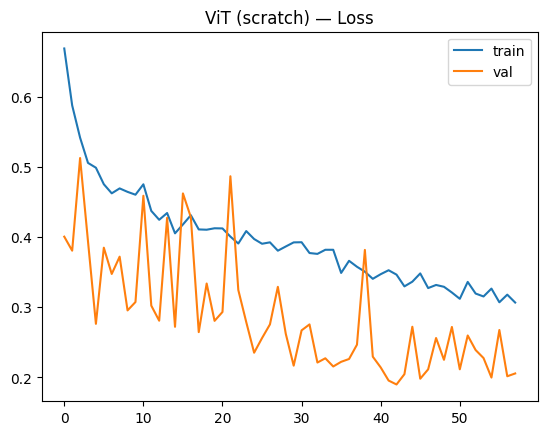

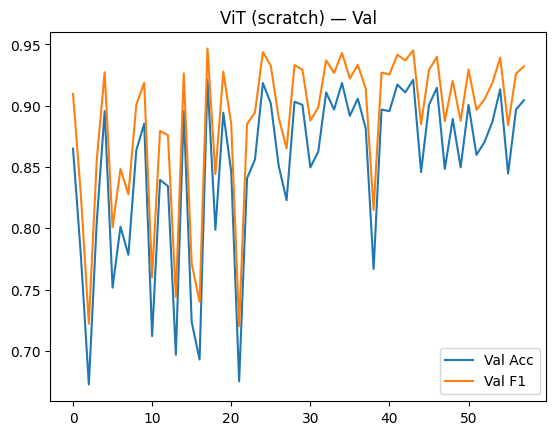

[ViT-scratch @0.5] {'acc': 0.8606, 'precision': 0.8633, 'recall': 0.9231, 'f1': 0.8922, 'auroc': 0.9204, 'thr': 0.5}
[ViT-scratch @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.9204, 'thr': 0.0067}


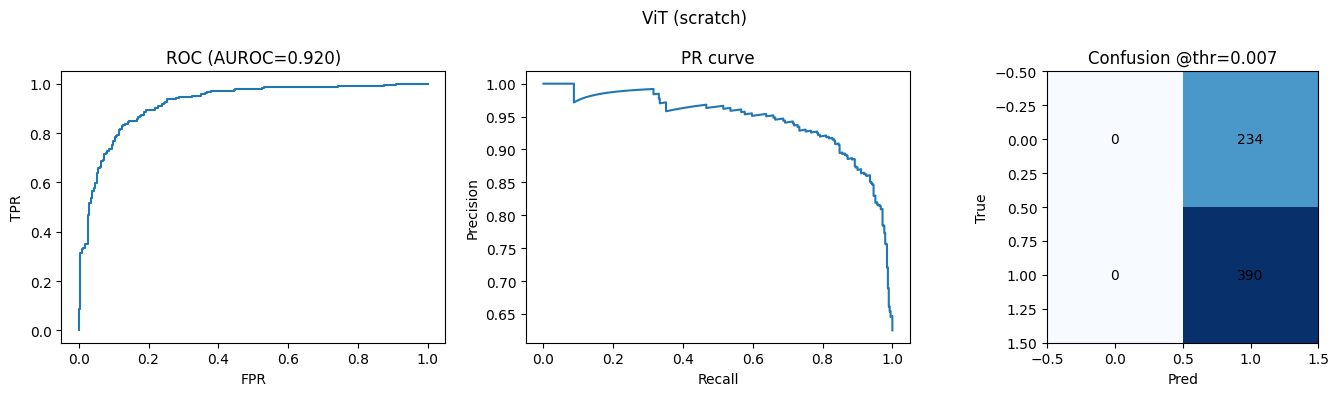

{'summary@0.5': {'acc': 0.8605769230769231,
  'precision': 0.8633093525179856,
  'recall': 0.9230769230769231,
  'f1': 0.8921933085501859,
  'auroc': 0.920359412667105,
  'thr': 0.5},
 'summary@recall': {'acc': 0.625,
  'precision': 0.625,
  'recall': 1.0,
  'f1': 0.7692307692307693,
  'auroc': 0.920359412667105,
  'thr': 0.0067491913214325905},
 'threshold': 0.0067491913214325905,
 'time_sec': 5928.4264969825745,
 'params': 21666434}

In [12]:
vit = build_vit_scratch(img_size=224, in_chans=3, num_classes=2,
                        embed_dim=384, depth=12, heads=6, patch=16, mlp_ratio=4.0, drop=0.1)
t0 = time.time()
vit_tr, vit_hist, vit_time = train_model(
    vit, train_loader, val_loader, DEVICE, arch="vit",
    epochs=100, base_lr=3e-4, weight_decay=0.3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.2,
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    monitor="va_auroc", patience=15, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=10.0, use_amp=False,
    tag="ViT-scratch"
)
vit_time = time.time() - t0

plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT (scratch) — Loss")
plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT (scratch) — Val")

va = evaluate(vit_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], scratch_cfg.target_recall)
te = evaluate(vit_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ViT-scratch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ViT-scratch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ViT (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ViT (scratch)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [13]:
import pandas as pd
from src import result_registry as RR

rows=[]
for name, d in RR.items():
    s = d.get("summary@recall", d.get("summary@0.5"))
    if not s: continue
    thr = d.get("threshold", s.get("thr", 0.5))
    rows.append({
        "Model": name,
        "Params (M)": round(d.get("params", 0)/1e6, 2) if d.get("params") else None,
        "Time (min)": round(d.get("time_sec", 0)/60, 2) if d.get("time_sec") else None,
        "Acc": round(s["acc"],4), "Prec": round(s["precision"],4),
        "Recall": round(s["recall"],4), "F1": round(s["f1"],4),
        "AUROC": round(s.get("auroc", float('nan')),4), "Thr": round(thr,3)
    })
df = pd.DataFrame(rows).sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
display(df); print(df.to_string(index=False))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,CustomCNN (scratch),0.48,171.26,0.625,0.625,1.0,0.7692,0.9523,0.000
1,ResNet18 (scratch),11.18,418.80,0.625,0.625,1.0,0.7692,0.9290,0.000
2,ViT (scratch),21.67,98.81,0.625,0.625,1.0,0.7692,0.9204,0.007


              Model  Params (M)  Time (min)   Acc  Prec  Recall     F1  AUROC   Thr
CustomCNN (scratch)        0.48      171.26 0.625 0.625     1.0 0.7692 0.9523 0.000
 ResNet18 (scratch)       11.18      418.80 0.625 0.625     1.0 0.7692 0.9290 0.000
      ViT (scratch)       21.67       98.81 0.625 0.625     1.0 0.7692 0.9204 0.007
